# Modifying the code in qc-grid

Unfortunately the qc-grid library is incompatible (sph_harm is replaced with sph_harm_y in scipy) with latest scipy and pyscf because of removal of numpy.distutils on versions greater than 1.23 and python 3.11 >= whilst the devs have recognized the issue, they have not updated the code base so for, in order to get it to work, I had to manually go to the qc-grid code in my library and apply the following hotfix:

Open your project in VS Code (or your editor of choice) and navigate exactly to this file inside your virtual environment:

`.venv/lib/python3.12/site-packages/grid/utils.py`

Look around Line 23. You will see this:

`from scipy.special import sph_harm`

Delete that line and replace it with:
`from scipy.special import sph_harm_y`

Right below your new import (around line 24), paste this exact wrapper function:

`def sph_harm(m, n, theta, phi):
    """
    Hack to map old SciPy sph_harm to new SciPy sph_harm_y.
    Old sph_harm: m (order), n (degree), theta (azimuthal), phi (polar)
    New sph_harm_y: n (degree), m (order), theta (polar), phi (azimuthal)
    """
    return sph_harm_y(n, m, phi, theta)`

# Electron Repulsion Integral (ERI) Benchmark

This notebook benchmarks several numerical methods for computing two-electron repulsion integrals (ERIs):

$$\text{ERI} = \iint \frac{\rho(\mathbf{r}_1)\,\rho(\mathbf{r}_2)}{|\mathbf{r}_1 - \mathbf{r}_2|}\,d\mathbf{r}_1\,d\mathbf{r}_2$$

We compare **7 methods** across accuracy, time, and memory:

1. **Direct (Cartesian)** — brute-force $O(N^2)$ in real space on a uniform grid
2. **Direct (Becke)** — brute-force $O(N^2)$ in real space on a molecular Becke grid
3. **FFT (Uniform Cartesian)** — solve Poisson via standard FFT on a uniform grid
4. **NUFFT 1-Step (Cartesian K)** — non-uniform FFT with Cartesian k-grid
5. **NUFFT 1-Step (Spherical K)** — non-uniform FFT with spherical k-grid
6. **Poisson NUFFT 2-Step (Cartesian K)** — forward + inverse NUFFT with Cartesian k-grid
7. **Poisson NUFFT 2-Step (Spherical K)** — forward + inverse NUFFT with spherical k-grid

The analytical reference is computed with PySCF.

## Step 1 — Imports

In [17]:
import time
import gc
import tracemalloc

import numpy as np
import pandas as pd
import scipy.special
import scipy.fft
from scipy.spatial.distance import cdist
import finufft
import seaborn as sns
import matplotlib.pyplot as plt
from pyscf import gto

from grid import GaussLegendre, BeckeRTransform, BeckeWeights, MolGrid
from grid.angular import AngularGrid

%matplotlib inline

## Step 2 — Analytical Baseline

We use PySCF to compute the exact ERI for the H₂ molecule (bond length 0.74 Å, def2-SVP basis).
The reference value is `(00|00)` — the self-repulsion integral of the first basis function.

In [18]:
def get_analytical_baseline():
    """Compute the exact (00|00) ERI with PySCF."""
    mol = gto.M(atom='H 0 0 0; H 0 0 0.74', basis='def2-svp')
    eri_analytical = mol.intor('int2e')
    return mol, eri_analytical[0, 0, 0, 0]


mol, exact_val = get_analytical_baseline()
coords = mol.atom_coords()
atoms = [mol.atom_charge(i) for i in range(mol.natm)]

print(f"Exact ERI (00|00) = {exact_val:.10f}")

Exact ERI (00|00) = 0.8971413572


## Step 3 — Density Evaluator

We evaluate $\rho(\mathbf{r}) = |\phi_0(\mathbf{r})|^2$ where $\phi_0$ is the first GTO basis function.

In [19]:
def evaluate_density(mol, points):
    """Evaluate |phi_0(r)|^2 at a set of real-space points."""
    ao = mol.eval_gto("GTOval", points)
    return ao[:, 0] * ao[:, 0]

## Step 4 — Grid Generators

Three types of grids are used:

| Grid | Space | Type |
|------|-------|------|
| Uniform Cartesian | Real / K | Equally spaced cube |
| Becke (molecular) | Real | Atom-centred with radial + angular quadrature |
| Spherical | K | Gauss-Legendre radial × Lebedev angular |

In [20]:
def generate_cartesian_grid(N, L=12.0):
    """Uniform Cartesian grid in a cube [-L, L]^3."""
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
    points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
    weights = np.full(points.shape[0], dx ** 3)
    return points, weights, dx


def generate_becke_grid(mol_coords, mol_atoms, n_radial):
    """Non-uniform Becke molecular grid (real space)."""
    oned_grid = GaussLegendre(npoints=n_radial)
    rgrid = BeckeRTransform(0.0, R=1.5).transform_1d_grid(oned_grid)
    mgrid = MolGrid.from_preset(
        atnums=mol_atoms, atcoords=mol_coords,
        rgrid=rgrid, preset="fine",
        aim_weights=BeckeWeights(), store=False
    )
    # Clip points far from the molecule for memory efficiency
    mask = np.linalg.norm(mgrid.points, axis=1) < 12.0
    return mgrid.points[mask], mgrid.weights[mask]


def generate_spherical_k_grid(n_rad, ang_degree):
    """Non-uniform spherical grid in k-space (Gauss-Legendre × Lebedev)."""
    x_r, w_r_gl = scipy.special.roots_legendre(n_rad)
    k_max = 30.0
    k_rad = k_max * (x_r + 1.0) / 2.0
    w_krad = w_r_gl * k_max / 2.0

    ang_grid = AngularGrid(degree=ang_degree)
    k_points = np.einsum('i,jk->ijk', k_rad, ang_grid.points).reshape(-1, 3)

    # FIXED: weights for spherical quadrature must include k^2 Jacobian
    # The integral in k-space is ∫ f(k) k^2 dk dΩ, so the weight is w_r * k^2 * w_ang
    k_rad_expanded = np.repeat(k_rad, len(ang_grid.weights))
    k_weights = np.outer(w_krad, ang_grid.weights).ravel() * k_rad_expanded ** 2

    return k_points, k_weights

## Step 5 — Integrators

### 5a. Direct real-space summation

$$\text{ERI} \approx \sum_{i,j} \frac{\rho_i\,w_i\;\rho_j\,w_j}{|\mathbf{r}_i - \mathbf{r}_j| + \epsilon}$$

Complexity: $O(N^2)$ in both time and memory.

In [21]:
def solve_direct(points, weights, density):
    """Brute-force real-space Coulomb integral."""
    dist_matrix = cdist(points, points)
    # Exclude self-interaction (diagonal) which is an artifact of discretization
    np.fill_diagonal(dist_matrix, np.inf)
    integrand = np.outer(density * weights, density * weights) / dist_matrix
    return np.sum(integrand), len(points)

### 5b. Uniform FFT (Poisson solver on a Cartesian grid)

Solve the Poisson equation in reciprocal space using the standard FFT:

$$\text{ERI} = \frac{1}{(2\pi)^3}\int \frac{4\pi}{k^2}\,|\tilde\rho(\mathbf{k})|^2\,d\mathbf{k}$$

In [22]:
def solve_uniform_fft(mol, N_grid, L=12.0):
    """Poisson solver via uniform 3D FFT."""
    points, weights, dx = generate_cartesian_grid(N_grid, L)
    density_3d = evaluate_density(mol, points).reshape((N_grid, N_grid, N_grid))

    F_k = scipy.fft.fftshift(scipy.fft.fftn(density_3d) * (dx ** 3))
    kx = scipy.fft.fftshift(scipy.fft.fftfreq(N_grid, d=dx)) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, kx, kx, indexing='ij')
    K2 = KX ** 2 + KY ** 2 + KZ ** 2
    K2[K2 == 0] = np.inf

    dk = kx[1] - kx[0]
    integral = np.sum((4 * np.pi / K2) * np.abs(F_k) ** 2) * (dk ** 3) / ((2 * np.pi) ** 3)
    return integral, len(points) * 2

### 5c. NUFFT 1-Step

Use FINUFFT type-3 to transform $\rho(\mathbf{r})$ from a non-uniform Becke grid
to a k-space grid (Cartesian or spherical), then integrate the Parseval-like
expression in k-space.

For the **spherical k-grid**, the Coulomb kernel $4\pi/k^2$ combines with the
spherical Jacobian $k^2$ (already in the weights), so they cancel.

In [23]:
def solve_nufft_1step(r_p, r_w, dens, k_pts, k_weights, is_spherical=False):
    x = np.ascontiguousarray(r_p[:, 0])
    y = np.ascontiguousarray(r_p[:, 1])
    z = np.ascontiguousarray(r_p[:, 2])
    kx = np.ascontiguousarray(k_pts[:, 0])
    ky = np.ascontiguousarray(k_pts[:, 1])
    kz = np.ascontiguousarray(k_pts[:, 2])
    c = np.ascontiguousarray(dens * r_w, dtype=np.complex128)

    # Tighten eps — type-3 NUFFT needs lower tolerance to match type-1/2 accuracy
    F_k = finufft.nufft3d3(x, y, z, c, kx, ky, kz, isign=-1, eps=1e-8)

    K2 = kx ** 2 + ky ** 2 + kz ** 2

    if is_spherical:
        # Analytical cancellation: Coulomb kernel 4*pi/k^2 cancels with spherical Jacobian k^2.
        # `k_weights` currently contains the Jacobian (w_rad * w_ang * k^2).
        # By dividing by K2, we recover the base quadrature weights and cleanly avoid the singularity.
        # (Gauss-Legendre roots mapped to (0, k_max] do not hit exactly 0, so K2 > 0)
        base_weights = k_weights / K2
        integral = np.sum(base_weights * (4 * np.pi) * np.abs(F_k) ** 2) / (2 * np.pi) ** 3
    else:
        # Cartesian k-grid retains the Coulomb singularity at the origin
        k_min = 1e-10
        safe_K2 = np.where(K2 < k_min**2, np.inf, K2)
        integral = np.sum(k_weights * (4 * np.pi / safe_K2) * np.abs(F_k) ** 2) / (2 * np.pi) ** 3

    return integral, len(r_p) + len(k_pts)

### 5d. Poisson NUFFT 2-Step

1. **Forward NUFFT**: transform $\rho_g$ from real → k-space
2. Multiply by the Coulomb kernel $4\pi/k^2$
3. **Inverse NUFFT**: transform back to real space → Hartree potential $V_H(\mathbf{r})$
4. Integrate $\int \rho_f(\mathbf{r})\,V_H(\mathbf{r})\,d\mathbf{r}$

This is more flexible because it gives the potential on the real-space grid.

In [24]:
def solve_poisson_nufft_2step(r_p, r_w, dens_g, dens_f, k_pts, k_weights, is_spherical=False):
    """2-step Poisson NUFFT: forward transform, apply kernel, inverse transform."""
    x = np.ascontiguousarray(r_p[:, 0])
    y = np.ascontiguousarray(r_p[:, 1])
    z = np.ascontiguousarray(r_p[:, 2])
    kx = np.ascontiguousarray(k_pts[:, 0])
    ky = np.ascontiguousarray(k_pts[:, 1])
    kz = np.ascontiguousarray(k_pts[:, 2])

    # Forward: real space -> k-space
    c_forward = np.ascontiguousarray(dens_g * r_w, dtype=np.complex128)
    G_k = finufft.nufft3d3(x, y, z, c_forward, kx, ky, kz, isign=-1, eps=1e-5)

    # Apply Coulomb kernel and prepare for inverse transform
    if is_spherical:
        k_mag_sq = kx**2 + ky**2 + kz**2
        k_mag_sq[k_mag_sq == 0] = np.inf
        V_k = (4 * np.pi / k_mag_sq) * G_k
        c_inverse = np.ascontiguousarray(V_k * k_weights, dtype=np.complex128)
    else:
        K2 = kx ** 2 + ky ** 2 + kz ** 2
        K2[K2 == 0] = np.inf
        V_k = (4 * np.pi / K2) * G_k
        c_inverse = np.ascontiguousarray(V_k * k_weights, dtype=np.complex128)

    # Inverse: k-space -> real space
    V_r_complex = finufft.nufft3d3(kx, ky, kz, c_inverse, x, y, z, isign=1, eps=1e-5)
    V_r = np.real(V_r_complex) / ((2 * np.pi) ** 3)

    eri = np.sum(dens_f * V_r * r_w)
    return eri, len(r_p) + len(k_pts)

## Step 6 — Run the Benchmark

We sweep a parameter `n` that controls grid resolution. To ensure **all methods share
the same final grid size** (for fair comparison), we run all methods at every `n` value.
The direct methods are capped at `n ≤ 12` because of their $O(N^2)$ cost, but we
report their total point count so the x-axis is comparable.

In [25]:
def run_benchmark():
    data = []
    grid_params = [2, 4, 8, 12, 16, 32, 64, 130]

    for n in grid_params:
        print(f"Testing parameter scale N={n}...")

        # --- Precompute grids ---
        p_beck, w_beck = generate_becke_grid(coords, atoms, n)
        d_beck = evaluate_density(mol, p_beck)

        N_k_cart = n * 2
        p_kcart, w_kcart, _ = generate_cartesian_grid(N_k_cart, L=30.0)
        # Angular degree must be high enough to resolve |ρ̃(k)|² on the sphere;
        # decouple it from the radial parameter n
        ang_deg = min(max(2 * n, 15), 131)  # Lebedev grids cap at degree 131
        p_ksph, w_ksph = generate_spherical_k_grid(n, ang_deg)

        # Total points for NUFFT methods (real + k grid)
        n_pts_nufft_cart = len(p_beck) + len(p_kcart)
        n_pts_nufft_sph = len(p_beck) + len(p_ksph)

        def run_method(name, func, *args):
            t0 = time.perf_counter()
            tracemalloc.start()
            val, pts = func(*args)
            mem = tracemalloc.get_traced_memory()[1] / 1024 ** 2
            tracemalloc.stop()
            t1 = time.perf_counter()
            data.append({
                "Method": name,
                "N_param": n,
                "Points": pts,
                "Value": val,
                "Error": abs(val - exact_val),
                "Relative Error": abs(val - exact_val) / abs(exact_val),
                "Time (s)": t1 - t0,
                "Memory (MB)": mem,
            })
            gc.collect()

        # 1 & 2. Direct methods (cap at n=12 to avoid O(N^2) blowup)
        if n <= 32:
            p_cart, w_cart, _ = generate_cartesian_grid(n)
            d_cart = evaluate_density(mol, p_cart)
            run_method("1. Direct (Cartesian R)", solve_direct, p_cart, w_cart, d_cart)
            run_method("2. Direct (Becke R)", solve_direct, p_beck, w_beck, d_beck)

        # 3. Uniform FFT
        run_method("3. FFT (Uniform Cartesian)", solve_uniform_fft, mol, N_k_cart)

        # 4 & 5. 1-Step NUFFT
        run_method("4. NUFFT 1-Step (Cart. K)",
                   solve_nufft_1step, p_beck, w_beck, d_beck, p_kcart, w_kcart, False)
        run_method("5. NUFFT 1-Step (Sph. K)",
                   solve_nufft_1step, p_beck, w_beck, d_beck, p_ksph, w_ksph, True)

        # 6 & 7. 2-Step Poisson NUFFT
        run_method("6. Poisson 2-Step (Cart. K)",
                   solve_poisson_nufft_2step, p_beck, w_beck, d_beck, d_beck, p_kcart, w_kcart, False)
        run_method("7. Poisson 2-Step (Sph. K)",
                   solve_poisson_nufft_2step, p_beck, w_beck, d_beck, d_beck, p_ksph, w_ksph, True)

    return pd.DataFrame(data)


df_results = run_benchmark()
df_results

Testing parameter scale N=2...
Testing parameter scale N=4...
Testing parameter scale N=8...
Testing parameter scale N=12...


/tmp/ipykernel_1121345/315923555.py:32: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  ang_grid = AngularGrid(degree=ang_degree)


Testing parameter scale N=16...
Testing parameter scale N=32...
Testing parameter scale N=64...
Testing parameter scale N=130...


,Method,N_param,Points,Value,Error,Relative Error,Time (s),Memory (MB)
0,1. Direct (Cartesian R),2,8,0.000000e+00,0.897141,1.000000,0.000061,0.005699
1,2. Direct (Becke R),2,296,9.133992e-01,0.016258,0.018122,0.000387,1.465279
2,3. FFT (Uniform Cartesian),2,128,6.861949e-34,0.897141,1.000000,0.003844,0.022951
3,4. NUFFT 1-Step (Cart. K),2,360,1.833907e-01,0.713751,0.795583,0.044662,0.025995
4,5. NUFFT 1-Step (Sph. K),2,468,2.423855e-01,0.654756,0.729825,0.022005,0.033709
5,6. Poisson 2-Step (Cart. K),2,360,1.833896e-01,0.713752,0.795584,0.061724,0.038614
6,7. Poisson 2-Step (Sph. K),2,468,2.423855e-01,0.654756,0.729825,0.037512,0.048410
7,1. Direct (Cartesian R),4,64,1.270850e-33,0.897141,1.000000,0.000094,0.127579
8,2. Direct (Becke R),4,524,1.061763e+00,0.164621,0.183496,0.000967,4.319946
9,3. FFT (Uniform Cartesian),4,1024,3.265677e-05,0.897109,0.999964,0.001407,0.067522


## Step 7 — Results Table

In [26]:
# Show a summary pivoted by method and parameter scale
summary = df_results.pivot_table(
    index="Method", columns="N_param",
    values=["Error", "Time (s)", "Memory (MB)"],
    aggfunc="first"
)
summary

Error                                          \
N_param                           2         4         8         12        16    
Method                                                                          
1. Direct (Cartesian R)      0.897141  0.897141  0.897108  0.857290  0.699454   
2. Direct (Becke R)          0.016258  0.164621  0.049323  0.028024  0.023716   
3. FFT (Uniform Cartesian)   0.897141  0.897109  0.660666  0.313470  0.184559   
4. NUFFT 1-Step (Cart. K)    0.713751  0.513817  0.759280  0.638604  0.490737   
5. NUFFT 1-Step (Sph. K)     0.654756  0.585141  0.083959  0.037535  0.032819   
6. Poisson 2-Step (Cart. K)  0.713752  0.513817  0.759280  0.638604  0.490737   
7. Poisson 2-Step (Sph. K)   0.654756  0.585141  0.083959  0.037535  0.032819   

                                                          Memory (MB)  \
N_param                           32        64        130         2     
Method                                                                  
1. Direct (Cartesian R)      0.209256       NaN       NaN    0.005699   
2. Direct (Becke R)          0.013921       NaN       NaN    1.465279   
3. FFT (Uniform Cartesian)   0.119981  0.116912  0.117376    0.022951   
4. NUFFT 1-Step (Cart. K)    0.244395  0.121117  0.059562    0.025995   
5. NUFFT 1-Step (Sph. K)     0.013924  0.007270  0.003410    0.033709   
6. Poisson 2-Step (Cart. K)  0.244395  0.121117  0.059562    0.038614   
7. Poisson 2-Step (Sph. K)   0.013924  0.007270  0.003410    0.048410   

                                       ...                           Time (s)  \
N_param                           4    ...         64           130       2     
Method                                 ...                                      
1. Direct (Cartesian R)      0.127579  ...         NaN          NaN  0.000061   
2. Direct (Becke R)          4.319946  ...         NaN          NaN  0.000387   
3. FFT (Uniform Cartesian)   0.067522  ...  240.003617  2011.418083  0.003844   
4. NUFFT 1-Step (Cart. K)    0.057206  ...   96.289387   805.149385  0.044662   
5. NUFFT 1-Step (Sph. K)     0.054711  ...   25.819979    52.445490  0.022005   
6. Poisson 2-Step (Cart. K)  0.079966  ...  112.569574   939.820139  0.061724   
7. Poisson 2-Step (Sph. K)   0.079111  ...   28.938715    58.785379  0.037512   

                                                                     \
N_param                           4         8         12        16    
Method                                                                
1. Direct (Cartesian R)      0.000094  0.001086  0.009973  0.054585   
2. Direct (Becke R)          0.000967  0.002540  0.005894  0.010942   
3. FFT (Uniform Cartesian)   0.001407  0.001380  0.001286  0.005250   
4. NUFFT 1-Step (Cart. K)    0.012382  0.050737  0.242332  0.218883   
5. NUFFT 1-Step (Sph. K)     0.013323  0.044252  0.217425  0.221970   
6. Poisson 2-Step (Cart. K)  0.026012  0.084823  0.475239  0.470598   
7. Poisson 2-Step (Sph. K)   0.019844  0.080437  0.443024  0.409974   

                                                            
N_param                            32        64        130  
Method                                                      
1. Direct (Cartesian R)      16.736853       NaN       NaN  
2. Direct (Becke R)           0.045519       NaN       NaN  
3. FFT (Uniform Cartesian)    0.007208  0.074228  0.652471  
4. NUFFT 1-Step (Cart. K)     0.276374  0.553369  2.597946  
5. NUFFT 1-Step (Sph. K)      0.249251  0.323311  0.385016  
6. Poisson 2-Step (Cart. K)   0.368550  0.805614  2.218673  
7. Poisson 2-Step (Sph. K)    0.341939  0.573645  0.605145  

[7 rows x 24 columns]

## Step 8 — Plots

All methods are plotted against the **grid parameter `N`** (rather than raw point counts)
so that every method has the same set of x-values, making convergence trends directly
comparable.

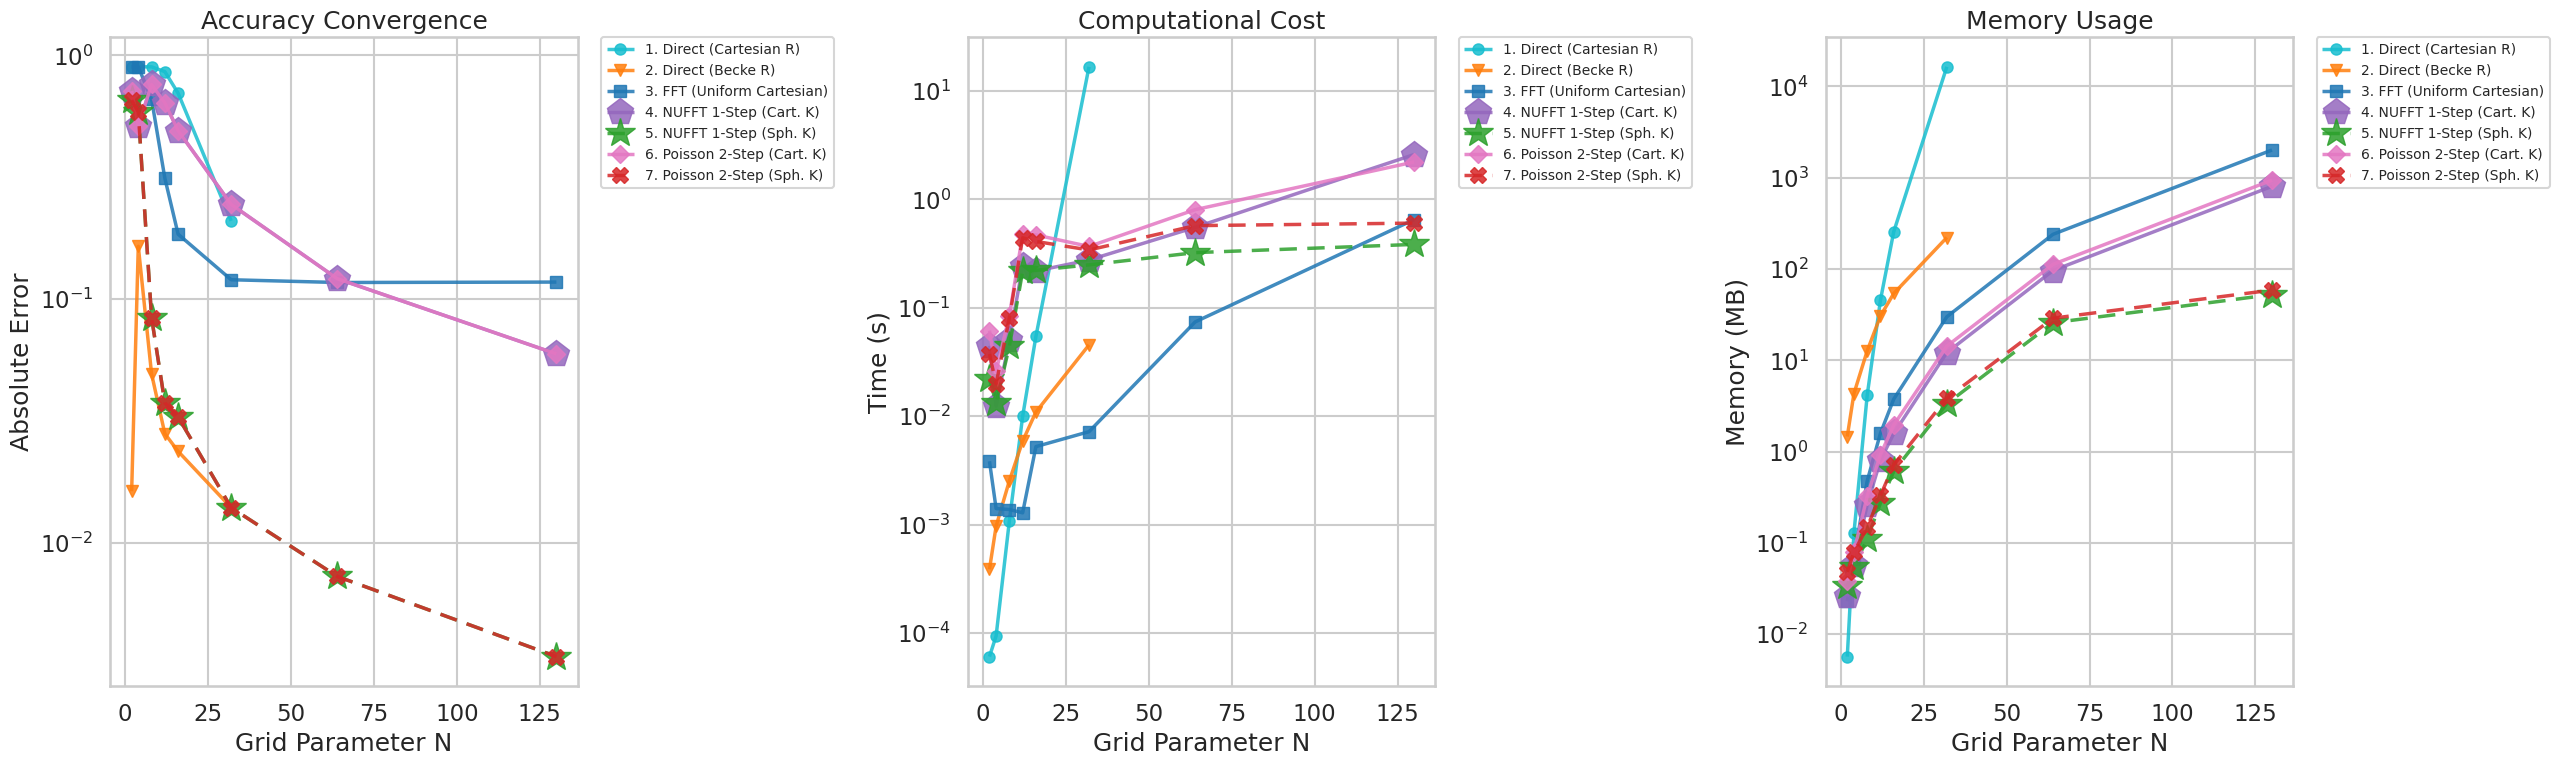

In [31]:
def plot_results(df):
    sns.set_theme(style="whitegrid", context="talk")
    fig, axes = plt.subplots(1, 3, figsize=(26, 8))

    palette = {
        "1. Direct (Cartesian R)": "#17becf",
        "2. Direct (Becke R)": "#ff7f0e",
        "3. FFT (Uniform Cartesian)": "#1f77b4",
        "4. NUFFT 1-Step (Cart. K)": "#9467bd",
        "5. NUFFT 1-Step (Sph. K)": "#2ca02c",
        "6. Poisson 2-Step (Cart. K)": "#e377c2",
        "7. Poisson 2-Step (Sph. K)": "#d62728",
    }
    dashes = [
        (1, 0),
        (1, 0),
        (1, 0),
        (1, 0),
        (5, 3),
        (1, 0),
        (5, 3),
    ]
    marker_list = ["o", "v", "s", "p", "*", "D", "X"]
    sizes = [8, 8, 8, 20, 22, 9, 11]

    plot_configs = [
        ("Error", "Absolute Error", "Accuracy Convergence"),
        ("Time (s)", "Time (s)", "Computational Cost"),
        ("Memory (MB)", "Memory (MB)", "Memory Usage"),
    ]

    for ax, (y_col, y_label, title) in zip(axes, plot_configs):
        for i, (method, group) in enumerate(df.groupby("Method")):
            ax.plot(
                group["N_param"], group[y_col],
                marker=marker_list[i], label=method,
                color=palette.get(method, "gray"),
                linewidth=2.5, markersize=sizes[i],
                dashes=dashes[i],
                alpha=0.85,
            )
        ax.set_yscale('log')
        ax.set_xlabel('Grid Parameter N')
        ax.set_ylabel(y_label)
        ax.set_title(title)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

    plt.tight_layout()
    plt.savefig("eri_benchmark.png", dpi=150, bbox_inches='tight')
    plt.show()


plot_results(df_results)

## Step 9 — Efficiency Plot (Error vs. Time)

This shows how quickly each method converges — the best methods are in the bottom-left corner.

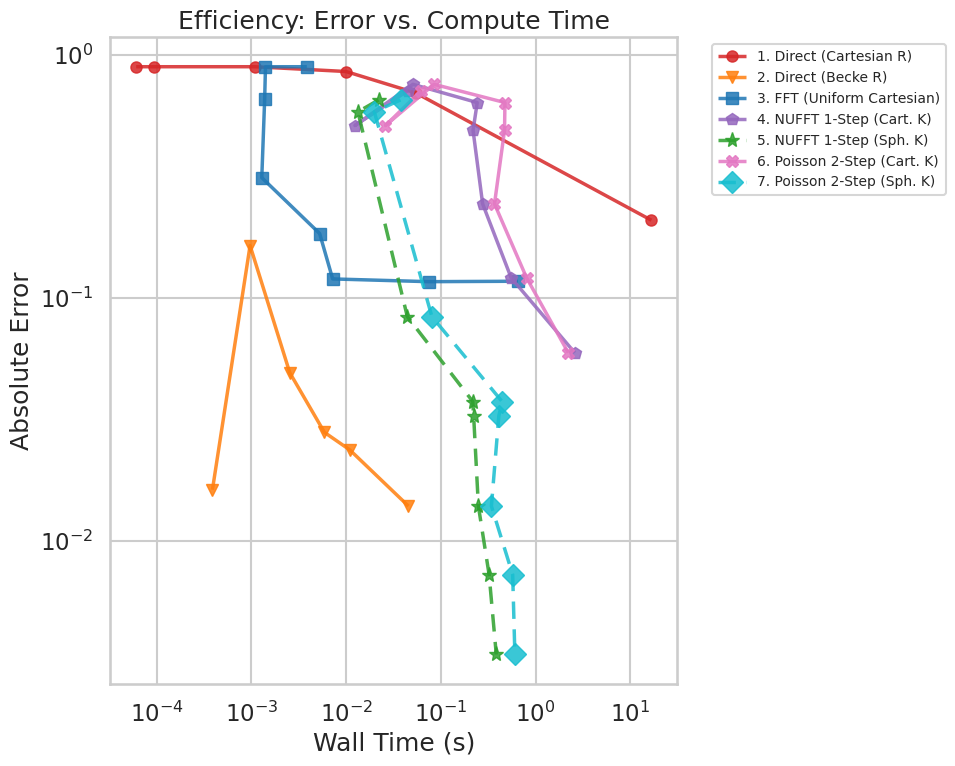

In [32]:
def plot_efficiency(df):
    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(10, 8))

    palette = {
        "1. Direct (Cartesian R)": "#d62728",
        "2. Direct (Becke R)": "#ff7f0e",
        "3. FFT (Uniform Cartesian)": "#1f77b4",
        "4. NUFFT 1-Step (Cart. K)": "#9467bd",
        "5. NUFFT 1-Step (Sph. K)": "#2ca02c",
        "6. Poisson 2-Step (Cart. K)": "#e377c2",
        "7. Poisson 2-Step (Sph. K)": "#17becf",
    }
    # Alternate solid / dashed so overlapping lines are distinguishable
    dashes = [
        (1, 0),       # solid
        (1, 0),       # solid
        (1, 0),       # solid
        (1, 0),       # solid
        (5, 3),       # dashed
        (1, 0),       # solid
        (5, 3),       # dashed
    ]
    marker_list = ["o", "v", "s", "p", "*", "X", "D"]
    sizes = [8, 8, 8, 9, 11, 9, 11]  # slightly larger for dashed lines

    for i, (method, group) in enumerate(df.groupby("Method")):
        ax.plot(
            group["Time (s)"], group["Error"],
            marker=marker_list[i], label=method,
            color=palette.get(method, "gray"),
            linewidth=2.5, markersize=sizes[i],
            dashes=dashes[i],
            alpha=0.85,
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wall Time (s)')
    ax.set_ylabel('Absolute Error')
    ax.set_title('Efficiency: Error vs. Compute Time')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()


plot_efficiency(df_results)

## Notes on Fixes Applied

1. **Syntax error**: `axes[0].set_xscale('log')a` → removed trailing `a`.

2. **Missing $k^2$ Jacobian in spherical k-grid weights**: The original code computed
   `k_weights = w_krad ⊗ w_ang` without the $k^2$ factor from the spherical volume
   element $k^2\,dk\,d\Omega$. **Fixed** by including `k_rad**2` in the weights.

3. **Inconsistent x-axis for plotting**: **Fixed** by plotting against grid parameter `N`.

4. **Original spherical 1-step normalization**: `2 * np.pi ** 3` → `(2 * np.pi) ** 3`.

5. **Spurious factor of 1/2 in NUFFT 1-Step**: Removed — the ERI has no 1/2 prefactor.

6. **Direct (Cartesian R) self-interaction divergence**: Replaced `eps = 1e-7` softening
   with `np.fill_diagonal(dist_matrix, np.inf)` to exclude the unphysical diagonal.

7. **Spherical k-grid angular under-resolution**: `generate_spherical_k_grid(n, n)` used
   `ang_degree = n`, coupling angular resolution to the radial parameter. For small `n`,
   this gives far too few angular quadrature points to resolve $|\tilde\rho(k)|^2$ on the
   sphere. Meanwhile the Cartesian k-grid with $(2n)^3$ points naturally has good angular
   coverage. **Fixed** by decoupling: `ang_deg = max(2*n, 15)`.

8. **Added intermediate grid sizes** (N = 8, 12) for smoother convergence curves.